In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import torch

import pytorch_lightning as pl
from pytorch_lightning.callbacks import (
    EarlyStopping,
    LearningRateMonitor,
    ModelCheckpoint,
    RichProgressBar,
)
from pytorch_lightning.loggers import TensorBoardLogger
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

from src.dataset import *
from src.lightning import *
from src.models import *
from src.params import *
from src.utils import *


# Callbacks, logger et trainers

In [2]:
callbacks = [
    ModelCheckpoint(
        dirpath="checkpoints/v2",
        monitor="val_loss",
        mode="min",
        save_top_k=1,
        save_last=True,
        filename="{epoch:02d}-{val_loss:.3f}-{val_kl:.3f}",
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=7,
        mode="min",
        min_delta=1e-4,
    ),
    LearningRateMonitor(logging_interval="epoch"),
    RichProgressBar(),
]

logger = TensorBoardLogger(save_dir="logs/", name="v2", version=None)


In [3]:
trainer_test = pl.Trainer(fast_dev_run=True, accelerator="auto", devices="auto")

trainer_full = pl.Trainer(
    max_epochs=50,
    accelerator="auto",
    devices="auto",
    precision="16-mixed",
    callbacks=callbacks,
    logger=logger,
    enable_progress_bar=True,
    log_every_n_steps=1,
)


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Running in `fast_dev_run` mode: will run the requested loop using 1 batch(es). Logging and checkpointing is suppressed.
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


## Instantiation

In [ ]:
files_dir = PROCESSED_DIR / "cropped"
metadata = pd.read_csv(DATA_DIR / "train.csv")
dm = BrainDataModule(metadata=metadata, spec_dir= files_dir, batch_size= 64, num_workers= 8)
model = BaselineModel(n_channels=4, n_classes=6)
lit_model = BrainLightning(model)


## Train

In [5]:
trainer_full.fit(lit_model, dm)


[setup] Loading splits from cache: /Users/pablorougerie/code/Projets/brain_waves/data/cache/5_at_seed_273.json
[setup] Cache loaded — 5 folds found
[Check] Train set distribution:
 expert_consensus
GPD        0.105983
GRDA       0.107885
LPD        0.151331
LRDA       0.054930
Other      0.425541
Seizure    0.154330
[Check] Val distribution:
 expert_consensus
GPD        0.106234
GRDA       0.107989
LPD        0.151302
LRDA       0.054726
Other      0.425519
Seizure    0.154229
[Check] Train: 13672 samples, 1558 patients
[Check] Val:   3417 samples, 392 patients
[Check] Top 5 patients train:
patient_id
30631    270
28330    250
38549    205
35225    189
56450    182
[Check] Top 5 patients val:
patient_id
17408    177
35627    171
1218     122
18815     92
55148     92


/Users/pablorougerie/code/Projets/brain_waves/.venv/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/pablorougerie/code/Projets/brain_waves/notebooks/checkpoints/v2 exists and is not empty.
/Users/pablorougerie/code/Projets/brain_waves/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ BaselineModel │  406 K │ train │     0 │
│ 1 │ criterion │ KLDivLoss     │      0 │ train │     0 │
│ 2 │ train_kl  │ KLDivergence  │      0 │ train │     0 │
│ 3 │ val_kl    │ KLDivergence  │      0 │ train │     0 │
└───┴───────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 406 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 406 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 37                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

Epoch 036 - train_loss: 0.5563 - train_kl: 0.5563

Epoch 037 | val_loss:   0.7526 | val_kl:   0.7526

Epoch 037 - train_loss: 0.5538 - train_kl: 0.5538

Epoch 038 | val_loss:   0.7621 | val_kl:   0.7621

Epoch 038 - train_loss: 0.5525 - train_kl: 0.5525

## Analyse

In [6]:
def plot_losses(log_dir="logs/v2"):
    versions = sorted(
        Path(log_dir).glob("version_*"),
        key=lambda p: int(p.name.split("_")[-1])
    )
    ea = EventAccumulator(str(versions[-1]))
    ea.Reload()

    def to_df(tag):
        events = ea.Scalars(tag)
        return pd.DataFrame({"epoch": [e.step for e in events], tag: [e.value for e in events]})

    train = to_df("train_loss")
    val   = to_df("val_loss")

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(train["epoch"], train["train_loss"], label="train loss")
    ax.plot(val["epoch"],   val["val_loss"],     label="val loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("KL Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


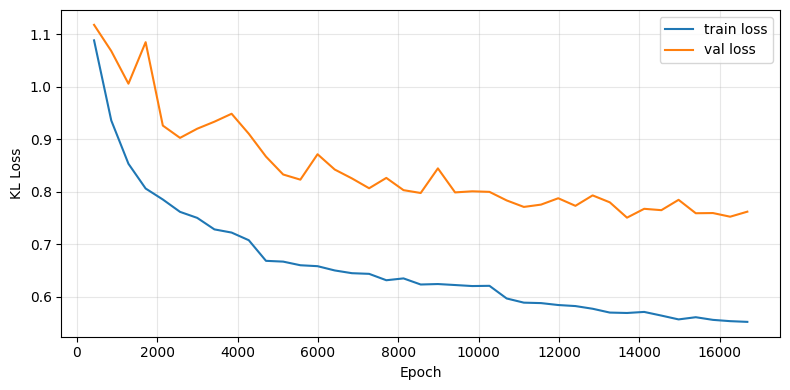

In [7]:
plot_losses()


In [8]:
best_score = callbacks[0].best_model_score
print(f"Best val_loss: {best_score:.4f}")

Best val_loss: 0.7508


# with Light Masking